## STOCHASTIC MODELING
MODULE 6 | LESSON 4


---



# **RL for Asset Allocation: Q-learning**

|  |  |
|:---|:---|
|**Reading Time** |  45 minutes |
|**Prior Knowledge** | MDP, Policy iteration, Portfolio rotation |
|**Keywords** | MDP, Q-learning


---

For the time period analyized, our RL Portfolio rotation algorithm does a very decent job. However, the policy iteration approach developed required us to take a stand on transition probabilities ($P$) and rewards ($R$). We estimated this using history (during training), which seemed representative, but it can very well be the case that transition probabilities and rewards estimated in a given period or under a certain model do not serve as good estimates for out of sample use. To overcome this potential limitation, a branch of RL developed the so-called **Q-learning** aproach, aiming at learning directly from experience about optimal actions.

In [1]:
# Import libraries to be used later on
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## **1. Q-learning**

The central change entailed by Q-learning is in the source of learning for our agent. Under the **policy iteration** approach, we estimated $R(s,a)$ and $P(s,s')$, then calculated value functions ($V^\pi$) and improved our policy until we achieved the optimal $\pi^*$.

**Q-learning** is a model-free approach: we do not need to estimate rewards nor transition probabilities, action values $Q(s,a)$ are directly learnt from the data.

**From state-value functons to action values ($Q$)**: In **Q-learning** the Bellman optimality is therefore set on $Q^*$:

$$
Q^*(s, a) = \mathbb{E}[r_{t+1} + \gamma \max_a' Q^*(s_{t+1}, a')| s_t = s, a_t = a]
$$

This Bellman equation contains both the **inmediate reward** as well as the **best continuation value**. This implies:

1. No need for a explicit definition of $P(s, s')$

2. Policy evaluation and improvement collapse into one 'update'. Each time step $Q$ updates toward optimal.


So, the so-called **greedy policy** is just:

$$
\pi(s) = arg max_a Q(s,a)
$$

But what is a greedy policy?

### 1.1. **Greedy and $ϵ$-greedy policies**

We have dealt already with greedy policies before implicitly, but not formally defined them. A **greedy policy** is simple a policy that always chooses the action with the highest known value. This implies some trade-offs:

- **Pros:**

  - A greedy policy is very simple to implement

  - Efficient in the long run when we are dealing with stable environments in which the optimal action is found quickly (easily).

- **Cons:**

  - We face the risk of finding (and getting stuck in) a local optima.

  - Because of its potentially narrow focus, it does not let the agent explore other potentially higher rewards that require **exploration**.


To illustrate this, think of the Gridworld example of Lesson 2, where we had a parameter that governed how much wandering we allowed the agent. In that simple example, we did not really require too much wandering because setting the optimal policy at each state was quite straightforward. But, this may not be the case for other more complex settings. In those, we may opt for **$\epsilon$-greedy** policies.

**$\epsilon$-greedy** policies allow the agent to balance the trade-off between **exploration and exploitations**. In practice, an **$\epsilon$-greedy** policy will choose, with probability $ϵ$, an action at random (exploration); and with probability $1-\epsilon$ the action with the highest estimated value (exploitation).

- **Pros:**

  - Balance of the exploration-exploitation trade-off, by ensuring that the agent continues to explore the environment for potentially higher rewards.

  - Avoids getting stuck in local optima

- **Cons:**

  - Can be inefficient if the value of $ϵ$ is too high, as the agent may waste a lot of time taking random actions.

  - Requires tuning the $\epsilon$ parameters, which can impact performance.

### 1.1. How does the agent learn the optimal policy?

To answer this question, we need to understand how are we going to update $Q(s_t, a_t)$. In other words, the **learning rule**. For a transition $(s_t, a_t, r_{t+1}, s_{t+1})$, this is:

$$
Q(s_t, a_t) ← Q(s_t,a_t) + \alpha \left[r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)  \right]
$$

where:

- $\alpha$ is the learning rate

- $\gamma$, as usual, is the discount rate

- The term $r_{t+1} + \gamma \max_{a'} Q(s_{t+1}, a')$ is usually called the temporal difference (TD) target.

So, in short, the agent learns by updating estimates using differences across time steps between a bootstrapped target (in this case, the max) and the current estimate. Of course, to maximize performance we can take $\alpha$ and $\gamma$ as model hyperparameters and tune them accordingly. We will explore this in the future. For now let's keep them with fixed values.


## **2. Q-learning and Portfolio rotation**

To implement our first Q-learning algorithm, let's go back to the portfolio rotation example from Lesson 3. Let's start by loading the data:

In [2]:
df = pd.read_csv("taa_monthly_data.csv", parse_dates=["date"], index_col="date")
df.head()

,px_spy,px_ief,px_shy,ret_spy,ret_ief,ret_shy
date,,,,,,
2004-01-31,75.756371,47.605370,55.095871,NaN,NaN,NaN
2004-02-29,76.784378,48.372673,55.362484,0.013570,0.016118,0.004839
2004-03-31,75.767365,49.000061,55.518364,-0.013245,0.012970,0.002816
2004-04-30,74.333755,46.870399,54.928692,-0.018921,-0.043462,-0.010621
2004-05-31,75.606583,46.621506,54.926003,0.017123,-0.005310,-0.000049


### 2.1. The portfolio rotation setup

As we know already, we need to define the RL setup. This will be equivalent to the one we defined in Lesson 3. Feel free to check it up for details on the code:

In [3]:
# Rolling features
roll6_spy = (1 + df["ret_spy"]).rolling(6).apply(np.prod, raw=True) - 1
roll6_ief = (1 + df["ret_ief"]).rolling(6).apply(np.prod, raw=True) - 1
vol12_spy = df["ret_spy"].rolling(12).std() * np.sqrt(12)

df["eq_mom"]   = np.where(roll6_spy > 0, "pos", "neg")
df["bond_mom"] = np.where(roll6_ief > 0, "pos", "neg")
df["vol_raw"]  = vol12_spy

# Lag all three by 1 month to avoid look-ahead
df[["eq_mom","bond_mom","vol_raw"]] = df[["eq_mom","bond_mom","vol_raw"]].shift(1)

# Compute volatility tertiles on TRAIN (and apply same cutoffs to TEST sample to avoid leakage)
train_mask = (df.index >= "2004-01-31") & (df.index <= "2013-12-31")


q1, q2 = df.loc[train_mask, "vol_raw"].quantile([1/3, 2/3])

def vol_bucket(v):
    if pd.isna(v): return np.nan
    if v <= q1:    return "low"
    if v <= q2:    return "mid"
    return "high"

df["vol_regime"] = df["vol_raw"].map(vol_bucket)

# Map to state_id in 1 to 12 id
eq_map, bond_map, vol_map = {"neg":0,"pos":1}, {"neg":0,"pos":1}, {"low":0,"mid":1,"high":2}
idx_eq   = df["eq_mom"].map(eq_map)
idx_bond = df["bond_mom"].map(bond_map)
idx_vol  = df["vol_regime"].map(vol_map)
df["state_id"] = (idx_eq*6 + idx_bond*3 + idx_vol + 1).astype("Int64")

print(df[["eq_mom","bond_mom","vol_regime","state_id"]].dropna().tail(5))

           eq_mom bond_mom vol_regime  state_id
date                                           
2025-06-30    neg      pos        mid         5
2025-07-31    pos      pos        mid        11
2025-08-31    pos      pos        mid        11
2025-09-30    pos      pos        mid        11
2025-10-31    pos      pos        mid        11


We will also need to define actions (but no transition probs since we are in Q-learning!) and the usual **train**, **validation**, and **test** splits. Validation here will be useful when we want to tune hyperparameters:

In [4]:
ACTIONS = [(1.0,0.0),(0.75,0.25),(0.5,0.5),(0.25,0.75),(0.0,1.0)]  # Eq,Bond
S, A = 12, 5
gamma = 0.99

val_mask   = (df.index >= "2014-01-31") & (df.index <= "2017-12-31")
test_mask  = (df.index >= "2018-01-31")

### 2.2. $\epsilon$-greedy, TD update and rewards

Next, we define our policy updates, together with some helper functions. Note that our **select_action** function implements the $\epsilon$-greedy policy; whereas **td_update** performs the recursive update of $Q(s,a)$:

In [5]:
def idx_state(s):   # map 1..12 -> 0..11
    return int(s) - 1

def select_action(Q, s_idx, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(A)
    row = Q[s_idx]
    return np.random.choice(np.flatnonzero(row == row.max()))  # greedy w/ tie-break

def td_update(Q, s, a, r, sp, alpha, gamma):
    target = r + gamma * Q[sp].max()
    Q[s, a] += alpha * (target - Q[s, a])

def r_next_equity_bond(row_next, a_idx):
    we, wb = ACTIONS[a_idx]
    return we*row_next.ret_spy + wb*row_next.ret_ief

### 2.3. Train using Q-learning

We can now define explicitly how are we going to train our model. This requires a bunch of choices that we can also decide on. We will set some initial values, and then see how we can tune these to maximize certain metrics in validation:

- We will use 150 epochs (that is, complete passess over the training sample to update Q).

- Set $\alpha = 0.1$

- We will start with an $ϵ = 0.2$, which will decrease through each epoch until having a value of $0.01$. This encourages the agent to do more exploration at the beginning, and sequentially tilt things toward more exploitation.

- Set initial Q-values of $0$ using the "optimistic" parameter. If we want the agent to face slightly optimistic Q-values at the begining, we could set this to 0.005, for instance. This will encourage more exploration by the agent. In any case this "optimism" will fade away as Q-values are updated.

In [6]:
def train_qlearning(df_train, alpha=0.10, eps_start=0.20, eps_end=0.01, epochs=150, optimistic=0.0):
    # Q shape [S,A]
    Q = np.full((S, A), optimistic, dtype=float)
    seq = df_train.dropna(subset=["state_id","ret_spy","ret_ief"])
    seq = seq[["state_id","ret_spy","ret_ief"]]

    for e in range(epochs):
        eps = eps_start + (eps_end - eps_start) * (e / max(1, epochs-1))

        for t in range(len(seq)-1):
            s  = idx_state(seq.iloc[t].state_id)
            sp = idx_state(seq.iloc[t+1].state_id)
            a  = select_action(Q, s, eps)
            r  = r_next_equity_bond(seq.iloc[t+1], a)
            td_update(Q, s, a, r, sp, alpha, gamma)
    return Q

### 2.4. Design greedy policy and backtest

Finally, before running our whole algorithm, we must choose the -optimal- greedy policy (the policy that selects the actions with maximimum Q value) after we have recursively updated $Q(s,a)$ in the previous step. Here, we also develop a function **backtest_policy** to quickly test, later on, the performance of a given policy. In this backtest is precisely where we include things like transaction costs, to fairly compare a static allocation with a dynamic one:

In [7]:
ACTIONS_DICT = {1:(1.0,0.0), 2:(0.75,0.25), 3:(0.5,0.5), 4:(0.25,0.75), 5:(0.0,1.0)}

def greedy_policy_from_Q(Q):
    best = Q.argmax(axis=1)
    return {s: int(a+1) for s, a in zip(range(1, S+1), best)}

def backtest_policy(df_slice, policy_dict, cost_bps=10):
    out = df_slice.copy()
    out = out.dropna(subset=["state_id","ret_spy","ret_ief"])
    out["action"] = out["state_id"].map(policy_dict).astype("Int64")

    we = out["action"].map(lambda a: ACTIONS_DICT[int(a)][0] if pd.notna(a) else np.nan)
    r_e_next = out["ret_spy"].shift(-1)
    r_b_next = out["ret_ief"].shift(-1)
    r_gross  = we * r_e_next + (1 - we) * r_b_next

    we_prev  = we.shift(1)
    turnover = (we - we_prev).abs().fillna(0.0)
    cost = (cost_bps / 10_000.0) * turnover
    r_net = (r_gross - cost).dropna()

    curve = (1 + r_net).cumprod()
    return r_net, curve


### 2.5. Validation step

The previous steps train our algorithm to select the optimal policy in-sample (i.e., during training). Ideally, we would like our algorithm to lear for our future choices (i.e. out of sample). To this end, we perfom a **validation step**, aimed at selecting the best combination of (hyper) parameters that maximizes performance out of sample, acknowledging that different time periods are inherently different and, thus, the optimal policy and parameters in sample may not coincide with the optimal values in another sample. The validation step will helps us by providing with an alternative sample, alledgedly different from the training one, to select these optimal parameter values and policies.

To that end, we try a bunch of choices for the hyperparameters setup in the following grid variable. We will then pick the best values for them based on the Sharpe Ratio obtained in validation:

In [8]:
grid = [
    # --- Baselines (no optimism) ---
    {"alpha":0.10, "epochs":150, "eps_start":0.20, "eps_end":0.01, "optimistic":0.00},
    {"alpha":0.05, "epochs":200, "eps_start":0.20, "eps_end":0.01, "optimistic":0.00},
    {"alpha":0.08, "epochs":250, "eps_start":0.15, "eps_end":0.01, "optimistic":0.00},
    {"alpha":0.12, "epochs":150, "eps_start":0.25, "eps_end":0.02, "optimistic":0.00},

    # --- With mild optimism (≈ +0.2% monthly) ---
    {"alpha":0.10, "epochs":150, "eps_start":0.15, "eps_end":0.01, "optimistic":0.002},
    {"alpha":0.05, "epochs":250, "eps_start":0.20, "eps_end":0.02, "optimistic":0.002},
    {"alpha":0.08, "epochs":200, "eps_start":0.20, "eps_end":0.01, "optimistic":0.002},
    {"alpha":0.12, "epochs":200, "eps_start":0.25, "eps_end":0.01, "optimistic":0.002},

    # --- Stronger optimism (≈ +0.5% monthly) ---
    {"alpha":0.10, "epochs":200, "eps_start":0.15, "eps_end":0.01, "optimistic":0.005},
    {"alpha":0.05, "epochs":300, "eps_start":0.20, "eps_end":0.01, "optimistic":0.005},
    {"alpha":0.08, "epochs":250, "eps_start":0.25, "eps_end":0.02, "optimistic":0.005},
    {"alpha":0.12, "epochs":200, "eps_start":0.20, "eps_end":0.01, "optimistic":0.005},

    # --- Lower ε floor (more greedy late) ---
    {"alpha":0.10, "epochs":250, "eps_start":0.20, "eps_end":0.005, "optimistic":0.00},
    {"alpha":0.08, "epochs":300, "eps_start":0.15, "eps_end":0.005, "optimistic":0.002},

    # --- Higher ε start (more exploration early) ---
    {"alpha":0.10, "epochs":150, "eps_start":0.30, "eps_end":0.02, "optimistic":0.00},
    {"alpha":0.05, "epochs":250, "eps_start":0.30, "eps_end":0.01, "optimistic":0.002},
]


In [9]:
def perf_from_monthly(r):
    r = r.dropna(); n = len(r); yrs = n/12
    cagr = (1+r).prod()**(1/yrs) - 1
    vol  = r.std() * np.sqrt(12)
    sr   = cagr/vol if vol>0 else np.nan
    return cagr, vol, sr

df_train = df.loc[train_mask]
df_val   = df.loc[val_mask]
results = []

print(f"Starting grid search with {len(grid)} configurations...\n")

for i, hp in enumerate(grid, 1):
    print(f"[{i}/{len(grid)}] Testing: alpha={hp['alpha']}, epochs={hp['epochs']}, "
          f"eps_start={hp['eps_start']}, eps_end={hp['eps_end']}, optimistic={hp['optimistic']}")
    
    Q = train_qlearning(df_train, **hp)
    pi = greedy_policy_from_Q(Q)
    r_val, _ = backtest_policy(df_val, pi, cost_bps=10)
    cagr, vol, sr = perf_from_monthly(r_val)
    
    print(f"    → Ann Return: {cagr:6.2%}, Ann Vol: {vol:6.2%}, Sharpe: {sr:5.2f}\n")
    
    results.append((hp, cagr, vol, sr))

print("Grid search complete!")

val_tbl = pd.DataFrame([
    {
        "alpha":hp["alpha"], "epochs":hp["epochs"], "eps_start":hp["eps_start"], "eps_end":hp["eps_end"],
        "optimistic":hp["optimistic"], "Ann Return":c, "Ann Vol":v, "Sharpe":s
    } for hp,c,v,s in results
])
val_tbl.sort_values("Sharpe", ascending=False, inplace=True)
val_tbl


Starting grid search with 16 configurations...

[1/16] Testing: alpha=0.1, epochs=150, eps_start=0.2, eps_end=0.01, optimistic=0.0
    → Ann Return:  7.80%, Ann Vol:  4.88%, Sharpe:  1.60

[2/16] Testing: alpha=0.05, epochs=200, eps_start=0.2, eps_end=0.01, optimistic=0.0
    → Ann Return:  9.78%, Ann Vol:  6.16%, Sharpe:  1.59

[3/16] Testing: alpha=0.08, epochs=250, eps_start=0.15, eps_end=0.01, optimistic=0.0
    → Ann Return:  6.33%, Ann Vol:  4.49%, Sharpe:  1.41

[4/16] Testing: alpha=0.12, epochs=150, eps_start=0.25, eps_end=0.02, optimistic=0.0
    → Ann Return:  4.70%, Ann Vol:  4.95%, Sharpe:  0.95

[5/16] Testing: alpha=0.1, epochs=150, eps_start=0.15, eps_end=0.01, optimistic=0.002
    → Ann Return:  4.90%, Ann Vol:  7.00%, Sharpe:  0.70

[6/16] Testing: alpha=0.05, epochs=250, eps_start=0.2, eps_end=0.02, optimistic=0.002
    → Ann Return:  8.11%, Ann Vol:  6.38%, Sharpe:  1.27

[7/16] Testing: alpha=0.08, epochs=200, eps_start=0.2, eps_end=0.01, optimistic=0.002
    → Ann

,alpha,epochs,eps_start,eps_end,optimistic,Ann Return,Ann Vol,Sharpe
8,0.10,200,0.15,0.010,0.005,0.094232,0.046695,2.018039
0,0.10,150,0.20,0.010,0.000,0.077958,0.048815,1.597017
1,0.05,200,0.20,0.010,0.000,0.097836,0.061591,1.588478
2,0.08,250,0.15,0.010,0.000,0.063289,0.044908,1.409309
5,0.05,250,0.20,0.020,0.002,0.081055,0.063823,1.269993
7,0.12,200,0.25,0.010,0.002,0.073885,0.062271,1.186502
6,0.08,200,0.20,0.010,0.002,0.066755,0.058591,1.139348
9,0.05,300,0.20,0.010,0.005,0.064577,0.057980,1.113781
11,0.12,200,0.20,0.010,0.005,0.068686,0.066561,1.031929
13,0.08,300,0.15,0.005,0.002,0.044291,0.044672,0.991484


In [10]:
# Pick best set of parameters in validation based on Sharpe Ratio
best_hp = val_tbl.iloc[0][["alpha","epochs","eps_start","eps_end","optimistic"]].to_dict()
best_hp["epochs"] = int(best_hp["epochs"])
Q_best  = train_qlearning(df_train, **best_hp)
PI_q    = greedy_policy_from_Q(Q_best)

# Test period
df_test = df.loc[test_mask]
r_q, curve_q = backtest_policy(df_test, PI_q, cost_bps=10)

# 60/40 baseline performance
r_6040 = (0.6*df_test["ret_spy"].shift(-1) + 0.4*df_test["ret_ief"].shift(-1)).dropna()
curve_6040 = (1 + r_6040).cumprod()

# Performance table (CAGR, Vol, Sharpe)
def make_perf_table(r_q, r_b):
    def row(r):
        c,v,s = perf_from_monthly(r); return [c,v,s]
    tbl = pd.DataFrame(
        [row(r_q), row(r_b)],
        index=["Q-learning policy","60/40"],
        columns=["Annualized Return","Annualized Volatility","Sharpe (rf=0)"]
    )
    pretty = tbl.copy()
    pretty["Annualized Return"]     = pretty["Annualized Return"].map(lambda x: f"{x:.2%}")
    pretty["Annualized Volatility"] = pretty["Annualized Volatility"].map(lambda x: f"{x:.2%}")
    pretty["Sharpe (rf=0)"]         = pretty["Sharpe (rf=0)"].map(lambda x: f"{x:.2f}")
    return tbl, pretty

perf_raw, perf_pretty = make_perf_table(r_q, r_6040)
print(perf_pretty)


                  Annualized Return Annualized Volatility Sharpe (rf=0)
Q-learning policy             8.23%                10.12%          0.81
60/40                         8.86%                10.91%          0.81


It seems that the performance of the two strategies now is very close!

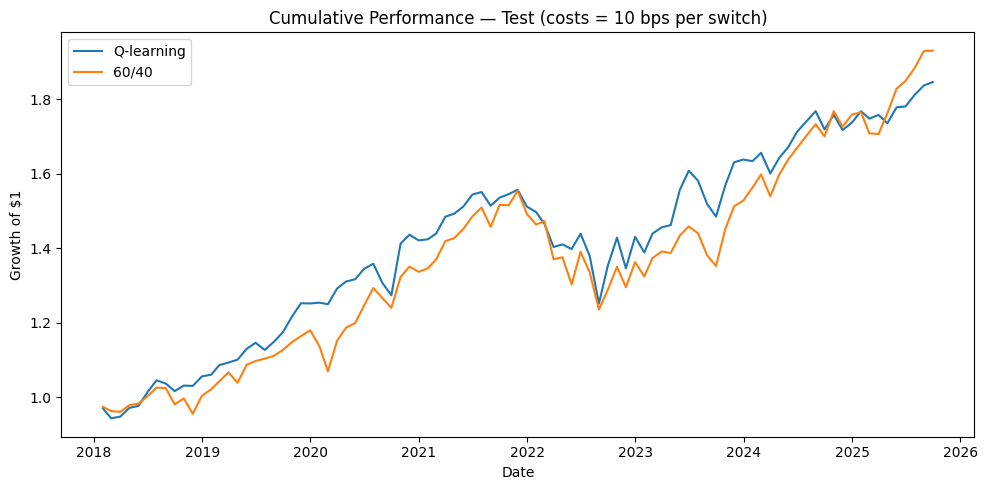

In [11]:
import matplotlib.pyplot as plt
curves = pd.DataFrame({"Q-learning":curve_q, "60/40":curve_6040}).dropna()
plt.figure(figsize=(10,5))
plt.plot(curves.index, curves["Q-learning"], label="Q-learning")
plt.plot(curves.index, curves["60/40"], label="60/40")
plt.title("Cumulative Performance — Test (costs = 10 bps per switch)")
plt.xlabel("Date"); plt.ylabel("Growth of $1"); plt.legend(); plt.tight_layout(); plt.show()


Now, it seems that the Q-learning algorithm does a poorer job than the more 'classic' policy iteration one. There are quite a number of things that will explain this poorer performance, for instance:

- Choices of parameter values: during validation, we let the algorithm decide upon a number of different predefined choices. Maybe the options we considered where not really the best.

- Train/Validation/Test sample: we choose a specific window for validation to select appropriate values for the hyperparameters. Maybe this validation window is not informative about the future market regimes and behavior of assets in the portfolio.

- Policy iteration just works better that Q-learning for this specific task: maybe the nature of the task makes it more appropriate to policy iteration algorithms that are model based.

- We got lucky in the policy iteration algorithm: another possibility is that we just got lucky with our policy iteration algorithm in the way it detects market regimes and appropriate actions. When dealing with this in practice we should as ourselves the most important question: if we got lucky, how far our luck is going to take us?

## **3. Conclusion**

Well done! In this lesson we have implemented a Portfolio rotation algorithm using Q-learning. As you can see, the performance for this specific task of policy iteration and Q-learning is slightly different. Keep in mind we have not "tuned" to its fullest the algorithm, so there's some potential room for improvement.

We will dig deeper into how to use more complex computational methods for portfolio management and trading, among other things, in subsequent courses. In the next module we will introduce another important topic: *Network theory*

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
